In [1]:
from __future__ import annotations

import numpy as np
import sympy as sp
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from config.CEQLConfig import ModelTrainingConfig, NomtoConfig
from src.ComplexEQL import ComplexEQL
from src.utils import set_seed, train
from src.sympy_utils import filter_imaginary_part

# Dataset

In [2]:
def generate_xy_dataset(
    n_samples: int = 1000,
    x_range: tuple[float, float] = (0.01, 2.0),   # x>0 to keep x^y real
    y_range: tuple[float, float] = (-2.0, 2.0),
):
    """
    Generate dataset for f(x, y) = x^y.
    We restrict x>0 so that x^y is real-valued for real y.
    Also filter out samples with |f| > 20 to avoid huge targets.
    """
    # sample x, y independently
    x = np.random.uniform(*x_range, size=(n_samples, 1))
    y = np.random.uniform(*y_range, size=(n_samples, 1))

    # compute function: f = x^y
    f = np.cos(x + y) + 2.0 * np.cos(y)  # shape (N,1)

    # filter out non-finite values (just in case) and |f| > 20
    mask = np.isfinite(f) & (np.abs(f) <= 100.0)
    x = x[mask]
    y = y[mask]
    f = f[mask]

    # reshape again so concatenation never fails
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    f = f.reshape(-1, 1)

    # concatenate safely: X = [x, y]
    X = np.concatenate([x, y], axis=1)

    return torch.from_numpy(X).float(), torch.from_numpy(f).float()

# Training

In [3]:
# -------------------------
# Config and setup
# -------------------------
mcfg = ModelTrainingConfig()
ncfg = NomtoConfig()

device = torch.device(mcfg.device)
set_seed(42)

# -------------------------
# Data
# -------------------------
X, y = generate_xy_dataset()
dataset = TensorDataset(X, y)
dataloader = DataLoader(
    dataset,
    batch_size=mcfg.train_batch_size,
    shuffle=True,
    drop_last=False,
)

# -------------------------
# Model, loss, optimizer, scheduler
# -------------------------
model = ComplexEQL(ncfg).to(device)

def complex_mse_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    # pred, target: complex tensors of shape (B,1)
    diff = pred - target
    return (diff.real**2 + diff.imag**2).mean()
    
loss_fn = nn.MSELoss()
# loss_fn = complex_mse_loss

optimizer = torch.optim.Adam(model.parameters(), lr=mcfg.lr)

if mcfg.scheduler == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, **mcfg.schedulerparams
    )
else:
    scheduler = None

# -------------------------
# Training
# -------------------------
model, (sl0_weights, sl1_weights, al_weights, imaginary_out_losses, data_losses) = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    cfg=mcfg,
    device=device,
    scheduler=scheduler,
)

# -------------------------
# Symbolic readout
# -------------------------
x_sym, y_sym = sp.symbols("x y")
symbolic_expr = model.get_symbolic_expression([x_sym, y_sym], rounding_decimals=2)
print("\nDiscovered expression:")
print(symbolic_expr)

Random seed set as 42
[Phase 1 | Epoch 1] total=2.8096e+00, data=2.8096e+00, sparsity_reg=0.0000e+00, imag_w=1.0361e-06, alpha=0.000e+00, imag_coeff=1.000e-06, lr=1.00e-03
[Phase 1 | Epoch 100] total=1.9990e+00, data=1.9990e+00, sparsity_reg=0.0000e+00, imag_w=7.7268e-06, alpha=0.000e+00, imag_coeff=7.780e-06, lr=1.00e-03
[Phase 1 | Epoch 200] total=1.5003e+00, data=1.5003e+00, sparsity_reg=0.0000e+00, imag_w=6.1717e-05, alpha=0.000e+00, imag_coeff=6.180e-05, lr=1.00e-03
[Phase 1 | Epoch 300] total=1.1901e+00, data=1.1895e+00, sparsity_reg=0.0000e+00, imag_w=5.5743e-04, alpha=0.000e+00, imag_coeff=4.909e-04, lr=1.00e-03
[Phase 1 | Epoch 400] total=9.8951e-01, data=9.8422e-01, sparsity_reg=0.0000e+00, imag_w=5.2821e-03, alpha=0.000e+00, imag_coeff=3.899e-03, lr=1.00e-03
[Phase 1 | Epoch 500] total=8.7318e-01, data=8.2942e-01, sparsity_reg=0.0000e+00, imag_w=4.3753e-02, alpha=0.000e+00, imag_coeff=3.097e-02, lr=1.00e-03
[Phase 1 | Epoch 600] total=9.5729e-01, data=7.1901e-01, sparsity_re

In [4]:
x_sym, y_sym = sp.symbols("x y")
symbolic_expr = model.get_symbolic_expression([x_sym, y_sym], rounding_decimals=2)
# symbolic_expr = filter_imaginary_part(symbolic_expr, [x_sym, y_sym])
print(symbolic_expr)

2.0*cos(1.0*y) + 1.0*cos(1.0*x + 1.0*y)


In [5]:
sp.simplify(symbolic_expr)

2.0*cos(1.0*y) + 1.0*cos(1.0*x + 1.0*y)

In [6]:
model.symbolic_layers[0].weights

Parameter containing:
tensor([[ 4.2039e-45+0.0000e+00j,  1.4929e-06+0.0000e+00j,
         -4.2039e-45+0.0000e+00j,  1.0000e+00-5.9153e-17j,
          5.4180e-06+0.0000e+00j],
        [ 0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          0.0000e+00+0.0000e+00j,  1.0000e+00+2.9779e-17j,
         -1.0000e+00+3.6070e-19j]], requires_grad=True)

In [7]:
model.assembly_layer.weights

Parameter containing:
tensor([[ 0.0000e+00+0.j],
        [ 4.2039e-45+0.j],
        [-4.2039e-45+0.j],
        [ 1.0000e+00+0.j],
        [ 2.0000e+00+0.j]], requires_grad=True)

# Visualize the predictions

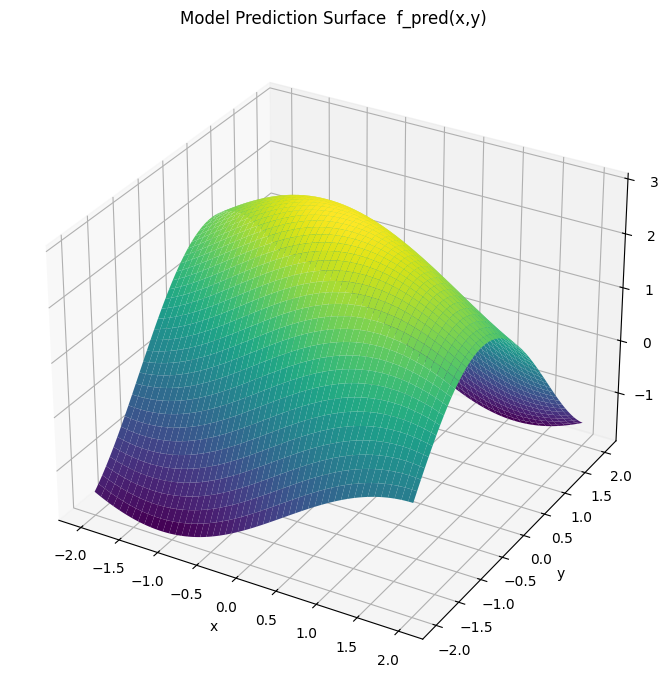

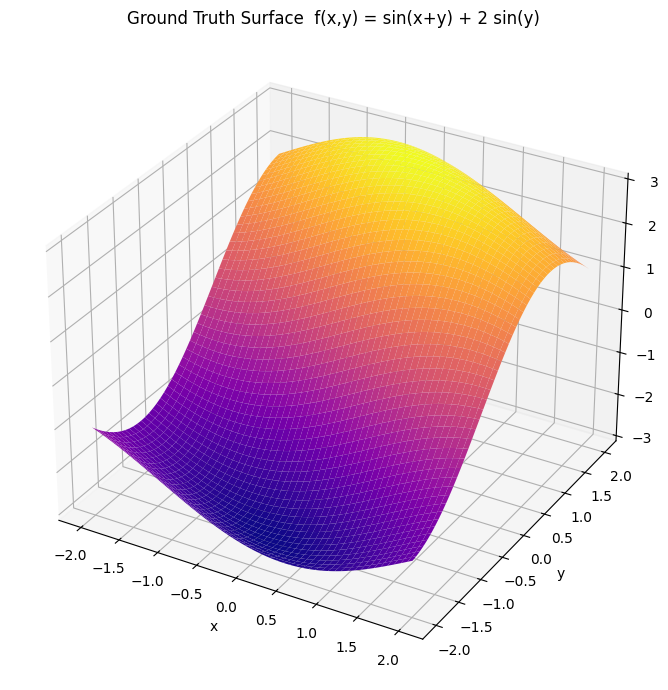

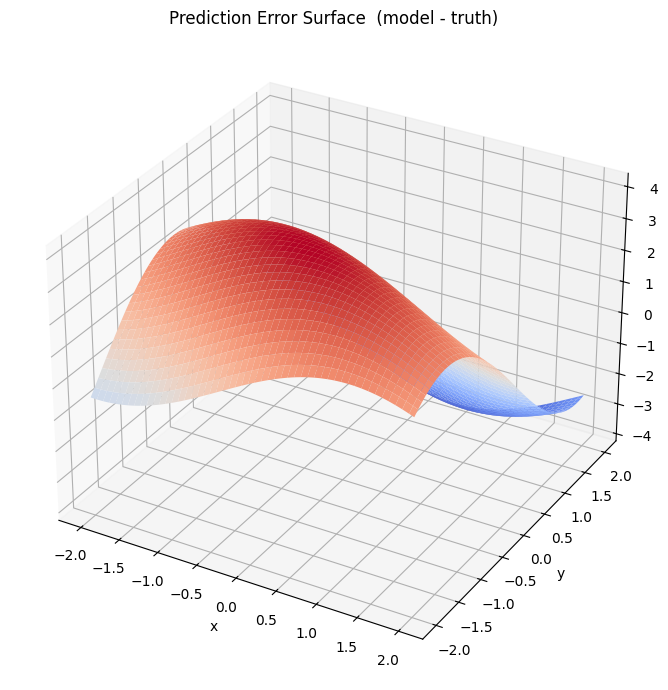

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # OK to keep

# -------------------------------------------------------
# Grid over (x, y) for visualization
# -------------------------------------------------------
x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0
grid_res = 200

xs = np.linspace(x_min, x_max, grid_res)
ys = np.linspace(y_min, y_max, grid_res)
Xg, Yg = np.meshgrid(xs, ys)

grid = np.stack([Xg, Yg], axis=-1)  # (R, R, 2)
grid_t = torch.from_numpy(grid.reshape(-1, 2)).float().to(device)

# -------------------------------------------------------
# Model predictions on grid
# -------------------------------------------------------
model.eval()
with torch.no_grad():
    pred = model(grid_t)  # (R*R, 1), complex
    pred_real = pred.real.cpu().numpy().reshape(grid_res, grid_res)

# -------------------------------------------------------
# Ground truth: f(x,y) = sin(x + y) + 2 sin(y)
# -------------------------------------------------------
f_true = np.sin(Xg + Yg) + 2.0 * np.sin(Yg)

# -------------------------------------------------------
# 3D plot: prediction surface
# -------------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Xg, Yg, pred_real, cmap="viridis", linewidth=0, antialiased=True)

ax.set_title("Model Prediction Surface  f_pred(x,y)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f_pred")

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 3D plot: ground truth surface
# -------------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Xg, Yg, f_true, cmap="plasma", linewidth=0, antialiased=True)

ax.set_title("Ground Truth Surface  f(x,y) = sin(x+y) + 2 sin(y)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f_true")

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 3D plot: prediction error surface
# -------------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

error = pred_real - f_true
ax.plot_surface(Xg, Yg, error, cmap="coolwarm", linewidth=0, antialiased=True)

ax.set_title("Prediction Error Surface  (model - truth)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("error")

plt.tight_layout()
plt.show()


# Visualize weights

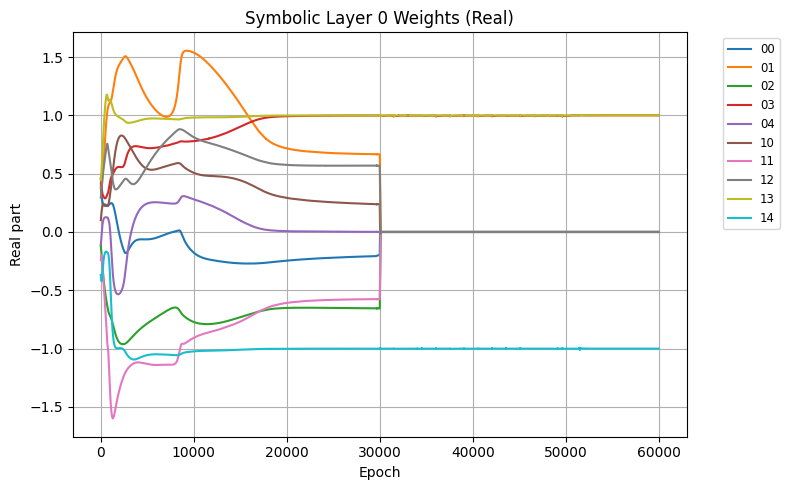

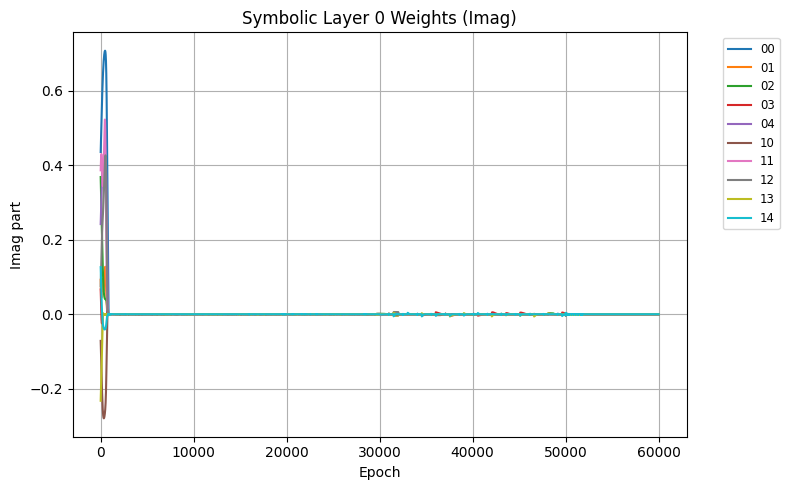

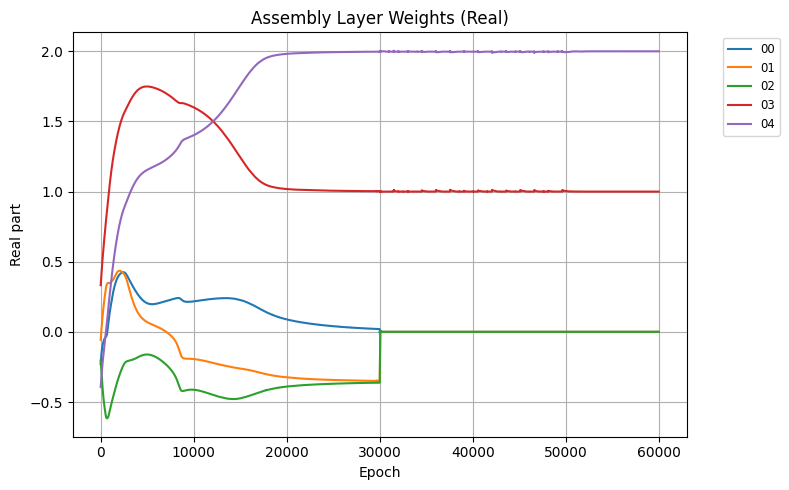

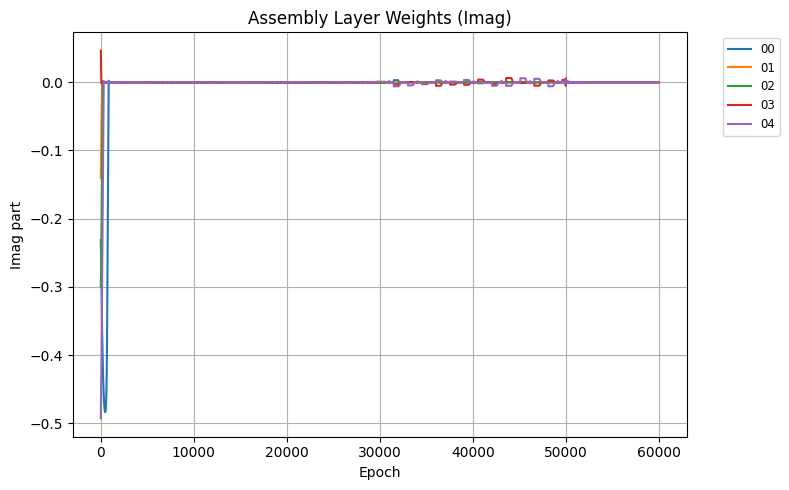

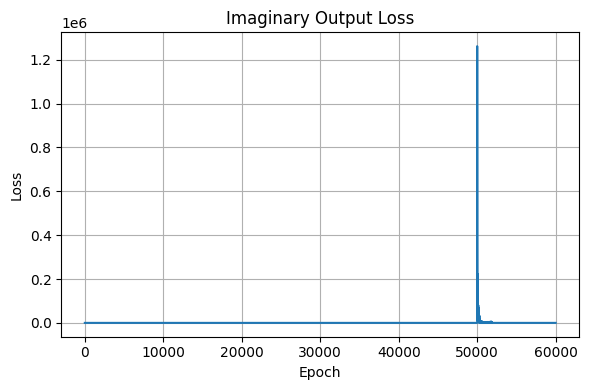

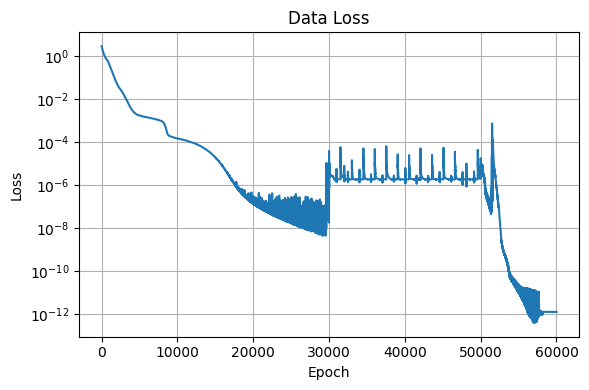

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Helper: flatten list of complex numpy arrays
# ----------------------------
def flatten_complex_list(weight_list):
    flat = [w.reshape(-1) for w in weight_list]
    mat = np.vstack(flat)
    return mat.real, mat.imag


# ==========================================================
# 1) Symbolic layer 0 weights
# ==========================================================
sl0_real, sl0_imag = flatten_complex_list(sl0_weights)
epochs0 = np.arange(len(sl0_real))

in_dim0, out_dim0 = sl0_weights[0].shape
labels_sl0 = [f"{i}{j}" for i in range(in_dim0) for j in range(out_dim0)]

# --- real part ---
plt.figure(figsize=(8, 5))
for k in range(sl0_real.shape[1]):
    plt.plot(epochs0, sl0_real[:, k], label=labels_sl0[k])
plt.title("Symbolic Layer 0 Weights (Real)")
plt.xlabel("Epoch")
plt.ylabel("Real part")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()

# --- imaginary part ---
plt.figure(figsize=(8, 5))
for k in range(sl0_imag.shape[1]):
    plt.plot(epochs0, sl0_imag[:, k], label=labels_sl0[k])
plt.title("Symbolic Layer 0 Weights (Imag)")
plt.xlabel("Epoch")
plt.ylabel("Imag part")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()


# ==========================================================
# 2) Assembly layer weights
# ==========================================================
al_real, al_imag = flatten_complex_list(al_weights)
epochs_al = np.arange(len(al_real))

labels_al = [f"{i:02d}" for i in range(al_real.shape[1])]

# --- real part ---
plt.figure(figsize=(8, 5))
for k in range(al_real.shape[1]):
    plt.plot(epochs_al, al_real[:, k], label=labels_al[k])
plt.title("Assembly Layer Weights (Real)")
plt.xlabel("Epoch")
plt.ylabel("Real part")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()

# --- imaginary part ---
plt.figure(figsize=(8, 5))
for k in range(al_imag.shape[1]):
    plt.plot(epochs_al, al_imag[:, k], label=labels_al[k])
plt.title("Assembly Layer Weights (Imag)")
plt.xlabel("Epoch")
plt.ylabel("Imag part")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()


# ==========================================================
# 3) Losses
# ==========================================================
imag_losses = np.array(imaginary_out_losses)
data_losses = np.array(data_losses)

# --- imaginary_out_losses ---
plt.figure(figsize=(6, 4))
plt.plot(imag_losses)
plt.title("Imaginary Output Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
# plt.yscale("log")
plt.tight_layout()

# --- data_losses (log scale) ---
plt.figure(figsize=(6, 4))
plt.plot(data_losses)
plt.title("Data Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")    # <<<<<< LOG SCALE HERE
plt.grid(True, which="both")
plt.tight_layout()

plt.show()
